# Notebook 5 - Benchmarks, metricas y analisis final

N5 integra todo el pipeline: compara estrategia frente a SPY, mide retorno/riesgo, evalua fricciones operativas y cuantifica robustez estadistica con Monte Carlo directo.

La meta de este cierre es defender con evidencia numerica si la estrategia aporta valor despues de costes y restricciones reales.


## Mapa del notebook

El flujo sigue una secuencia de decisi?n: primero se valida la comparabilidad temporal, despu?s se miden m?tricas y patrones de comportamiento, luego se eval?an fricciones operativas y finalmente se contrasta robustez con Monte Carlo directo y sensibilidad param?trica.


In [1]:
import time
import re
from math import ceil

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (14, 7)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11

N1_RUNTIME_PARAMS_PATH = "data/processed/n1_runtime_params.csv"
N1_BENCHMARK_PROVENANCE_PATH = "data/processed/n1_benchmark_provenance.csv"
N2_SIGNALS_INPUT_PATH = "data/processed/n2_signals_input.parquet"
N4_DAILY_PATH = "data/processed/n4_portfolio_daily.csv"
N4_ORDERS_PATH = "data/processed/n4_orders_log.csv"
N4_COST_SUMMARY_PATH = "data/processed/n4_cost_summary.csv"
N4_REBALANCE_SUMMARY_PATH = "data/processed/n4_rebalance_summary.csv"
N4_CHECKS_PATH = "data/processed/n4_checks.csv"

TRADING_DAYS = 252
RF_ANNUAL = 0.0
RF_DAILY = (1 + RF_ANNUAL) ** (1 / TRADING_DAYS) - 1

N_MONKEYS = 25_000_000
MONKEY_SEED = 42
MONKEY_PORTFOLIO_SIZE = 20
MONKEY_MONTHLY_COST = 0.0046
MONKEY_BATCH_SIZE = 250_000
MONKEY_PLOT_SAMPLE_N = 1_000_000
N_MONKEYS_PARAM_SENS = 5_000_000

In [2]:
def fail_if(condition: bool, message: str) -> None:
    if condition:
        raise ValueError(message)


def cagr_from_daily(ret: pd.Series, days_per_year: int = 252) -> float:
    ret = ret.dropna()
    if len(ret) == 0:
        return np.nan
    total = float((1 + ret).prod())
    years = len(ret) / days_per_year
    return total ** (1 / years) - 1 if years > 0 else np.nan


def annualized_vol(ret: pd.Series, days_per_year: int = 252) -> float:
    return float(ret.dropna().std(ddof=1) * np.sqrt(days_per_year))


def sharpe_from_daily(ret: pd.Series, rf_daily: float = 0.0, days_per_year: int = 252) -> float:
    x = ret.dropna()
    if len(x) == 0:
        return np.nan
    ex = x - rf_daily
    den = ex.std(ddof=1)
    if den <= 0 or np.isnan(den):
        return np.nan
    return float(np.sqrt(days_per_year) * ex.mean() / den)


def sortino_from_daily(ret: pd.Series, rf_daily: float = 0.0, days_per_year: int = 252) -> float:
    x = ret.dropna()
    if len(x) == 0:
        return np.nan
    ex = x - rf_daily
    downside = ex[ex < 0]
    den = downside.std(ddof=1)
    if den <= 0 or np.isnan(den):
        return np.nan
    return float(np.sqrt(days_per_year) * ex.mean() / den)


def max_drawdown_from_returns(ret: pd.Series) -> float:
    x = ret.dropna()
    if len(x) == 0:
        return np.nan
    wealth = (1 + x).cumprod()
    drawdown = wealth / wealth.cummax() - 1
    return float(drawdown.min())

In [3]:
def beta_alpha_daily(strategy_ret: pd.Series, benchmark_ret: pd.Series, rf_daily: float = 0.0, days_per_year: int = 252):
    x = pd.concat([strategy_ret, benchmark_ret], axis=1).dropna()
    x.columns = ["strategy", "benchmark"]
    if len(x) < 2:
        return np.nan, np.nan
    ex_s = x["strategy"] - rf_daily
    ex_b = x["benchmark"] - rf_daily
    var_b = ex_b.var(ddof=1)
    if var_b <= 0 or np.isnan(var_b):
        return np.nan, np.nan
    beta = ex_s.cov(ex_b) / var_b
    alpha_daily = ex_s.mean() - beta * ex_b.mean()
    alpha_annual = (1 + alpha_daily) ** days_per_year - 1
    return float(beta), float(alpha_annual)


def sample_without_replacement_rows(rng: np.random.Generator, n_rows: int, n_assets: int, k: int) -> np.ndarray:
    fail_if(k > n_assets, f"No se puede samplear k={k} sin reemplazo de n_assets={n_assets}")
    idx = rng.integers(0, n_assets, size=(n_rows, k), dtype=np.int32)
    if k <= 1:
        return idx
    while True:
        idx_sorted = np.sort(idx, axis=1)
        bad_rows = (np.diff(idx_sorted, axis=1) == 0).any(axis=1)
        n_bad = int(bad_rows.sum())
        if n_bad == 0:
            break
        idx[bad_rows] = rng.integers(0, n_assets, size=(n_bad, k), dtype=np.int32)
    return idx

In [4]:
runtime_params_df = pd.read_csv(N1_RUNTIME_PARAMS_PATH)
benchmark_prov = pd.read_csv(N1_BENCHMARK_PROVENANCE_PATH)
signals_input = pd.read_parquet(N2_SIGNALS_INPUT_PATH)
portfolio_daily = pd.read_csv(N4_DAILY_PATH, parse_dates=["date"])
orders = pd.read_csv(N4_ORDERS_PATH, parse_dates=["date", "proxy_price_date"])
cost_summary = pd.read_csv(N4_COST_SUMMARY_PATH)
rebalance_summary = pd.read_csv(N4_REBALANCE_SUMMARY_PATH, parse_dates=["date"])
n4_checks = pd.read_csv(N4_CHECKS_PATH)

required_runtime_cols = {"parameter", "value"}
required_portfolio_cols = {"date", "equity", "daily_return", "cash", "n_positions"}
required_orders_cols = {"date", "status", "reason", "fee", "notional", "side"}
required_signals_cols = {"rebalance_date", "symbol", "eligible_for_signals", "close_rebalance"}

fail_if(not required_runtime_cols.issubset(runtime_params_df.columns), "n1_runtime_params.csv invalido")
fail_if(not required_portfolio_cols.issubset(portfolio_daily.columns), "n4_portfolio_daily.csv invalido")
fail_if(not required_orders_cols.issubset(orders.columns), "n4_orders_log.csv invalido")
fail_if(not required_signals_cols.issubset(signals_input.columns), "n2_signals_input.parquet invalido")
fail_if(len(cost_summary) == 0, "n4_cost_summary.csv vacio")
fail_if(len(benchmark_prov) == 0, "n1_benchmark_provenance.csv vacio")

runtime_params = dict(zip(runtime_params_df["parameter"], runtime_params_df["value"]))
benchmark_path = runtime_params.get("benchmark_parquet", "data/raw/spy_yfinance.parquet")
spy = pd.read_parquet(benchmark_path)
fail_if(not {"date", "close"}.issubset(spy.columns), f"Benchmark invalido: {benchmark_path}")
spy["date"] = pd.to_datetime(spy["date"])

fee_rate = float(runtime_params.get("transaction_fee_rate", 0.0023))
fee_min = float(runtime_params.get("min_fee_per_order", 23.0))

input_overview = pd.DataFrame(
    [
        {
            "benchmark_path": benchmark_path,
            "portfolio_daily_rows": int(len(portfolio_daily)),
            "orders_rows": int(len(orders)),
            "signals_input_rows": int(len(signals_input)),
        }
    ]
)
display(input_overview)


,benchmark_path,portfolio_daily_rows,orders_rows,signals_input_rows
0,data/raw/spy_yfinance.parquet,2787,3639,64557


### Interpretacion: ventana comun, calidad de inputs y supuestos

Este bloque certifica que los artefactos de N1/N2/N4 y el benchmark son compatibles antes de calcular rendimiento. El resultado clave es que la base estructural permite comparar sin ruido de esquema. La lectura pr?ctica es que cualquier diferencia posterior responde a comportamiento financiero y no a errores de integraci?n. La limitaci?n es que validar estructura no implica validar causalidad econ?mica de cada observaci?n.


In [5]:
portfolio_daily = portfolio_daily.sort_values("date").reset_index(drop=True)
spy = spy.sort_values("date").reset_index(drop=True)

strategy_daily = portfolio_daily[["date", "daily_return", "equity", "cash", "n_positions"]].copy()
strategy_daily = strategy_daily.set_index("date")

spy_daily = spy[["date", "close"]].copy().set_index("date")
spy_daily["spy_return"] = spy_daily["close"].pct_change()

common_dates = strategy_daily.index.intersection(spy_daily.index)
returns_daily = pd.DataFrame(
    {
        "strategy": strategy_daily.loc[common_dates, "daily_return"],
        "spy": spy_daily.loc[common_dates, "spy_return"],
    }
).dropna()

fail_if(len(returns_daily) == 0, "No hay interseccion estrategia-SPY")

comparison_window = pd.DataFrame(
    [
        {
            "common_start": returns_daily.index.min().date(),
            "common_end": returns_daily.index.max().date(),
            "daily_observations": int(len(returns_daily)),
        }
    ]
)
display(comparison_window)


,common_start,common_end,daily_observations
0,2015-01-05,2026-01-30,2785


In [6]:
monthly_returns = (1 + returns_daily).resample("ME").prod() - 1
quarterly_returns = (1 + returns_daily).resample("QE").prod() - 1
annual_returns = (1 + returns_daily).resample("YE").prod() - 1

fail_if(monthly_returns.isna().all().any(), "Hay columnas completamente NaN en monthly_returns")
fail_if(quarterly_returns.isna().all().any(), "Hay columnas completamente NaN en quarterly_returns")
fail_if(annual_returns.isna().all().any(), "Hay columnas completamente NaN en annual_returns")

coverage_table = pd.DataFrame(
    {
        "frequency": ["daily", "monthly", "quarterly", "annual"],
        "n_obs": [len(returns_daily), len(monthly_returns), len(quarterly_returns), len(annual_returns)],
        "start": [
            returns_daily.index.min().date(),
            monthly_returns.index.min().date(),
            quarterly_returns.index.min().date(),
            annual_returns.index.min().date(),
        ],
        "end": [
            returns_daily.index.max().date(),
            monthly_returns.index.max().date(),
            quarterly_returns.index.max().date(),
            annual_returns.index.max().date(),
        ],
    }
)

coverage_table

,frequency,n_obs,start,end
0,daily,2785,2015-01-05,2026-01-30
1,monthly,133,2015-01-31,2026-01-31
2,quarterly,45,2015-03-31,2026-03-31
3,annual,12,2015-12-31,2026-12-31


### Interpretacion: alineacion temporal y sesgo de calendario

Aqu? se verifica que estrategia y SPY se midan en exactamente la misma ventana efectiva. El resultado clave es que las frecuencias mensual, trimestral y anual heredan esa intersecci?n diaria com?n. La lectura es que las m?tricas relativas quedan limpias de sesgo de calendario. La limitaci?n es que esta alineaci?n no corrige sesgos de construcci?n del universo aguas arriba.


In [7]:
beta, alpha = beta_alpha_daily(returns_daily["strategy"], returns_daily["spy"], RF_DAILY, TRADING_DAYS)

metrics_table = pd.DataFrame(
    [
        {"metric": "CAGR", "strategy": cagr_from_daily(returns_daily["strategy"], TRADING_DAYS), "spy": cagr_from_daily(returns_daily["spy"], TRADING_DAYS)},
        {"metric": "Volatility (annualized)", "strategy": annualized_vol(returns_daily["strategy"], TRADING_DAYS), "spy": annualized_vol(returns_daily["spy"], TRADING_DAYS)},
        {"metric": "Sharpe", "strategy": sharpe_from_daily(returns_daily["strategy"], RF_DAILY, TRADING_DAYS), "spy": sharpe_from_daily(returns_daily["spy"], RF_DAILY, TRADING_DAYS)},
        {"metric": "Sortino", "strategy": sortino_from_daily(returns_daily["strategy"], RF_DAILY, TRADING_DAYS), "spy": sortino_from_daily(returns_daily["spy"], RF_DAILY, TRADING_DAYS)},
        {"metric": "Max Drawdown", "strategy": max_drawdown_from_returns(returns_daily["strategy"]), "spy": max_drawdown_from_returns(returns_daily["spy"])},
        {"metric": "Beta (vs SPY)", "strategy": beta, "spy": 1.0},
        {"metric": "Alpha Jensen (annualized)", "strategy": alpha, "spy": 0.0},
    ]
)

assumptions_table = pd.DataFrame(
    [
        {"assumption": "Date window (common)", "value": f"{returns_daily.index.min().date()} -> {returns_daily.index.max().date()}"},
        {"assumption": "Risk-free annual", "value": f"{RF_ANNUAL:.2%}"},
        {"assumption": "Risk-free daily", "value": f"{RF_DAILY:.6%}"},
        {"assumption": "Annualization days", "value": TRADING_DAYS},
    ]
)

display(metrics_table)
display(assumptions_table)


,metric,strategy,spy
0,CAGR,0.120168,0.116153
1,Volatility (annualized),0.241613,0.178155
2,Sharpe,0.591131,0.706251
3,Sortino,0.761698,0.860564
4,Max Drawdown,-0.404871,-0.341047
5,Beta (vs SPY),1.060630,1.000000
6,Alpha Jensen (annualized),0.009418,0.000000


,assumption,value
0,Date window (common),2015-01-05 -> 2026-01-30
1,Risk-free annual,0.00%
2,Risk-free daily,0.000000%
3,Annualization days,252


### Interpretacion de metricas obligatorias

La tabla sintetiza retorno compuesto, riesgo absoluto, riesgo bajista y sensibilidad al benchmark. El resultado clave es disponer de un bloque ?nico con CAGR, Vol, Sharpe, Sortino, MaxDD, Beta y Alpha. La lectura correcta exige mirar el conjunto, no una m?trica aislada. La limitaci?n es que Beta y Alpha dependen del periodo y del supuesto lineal del CAPM.


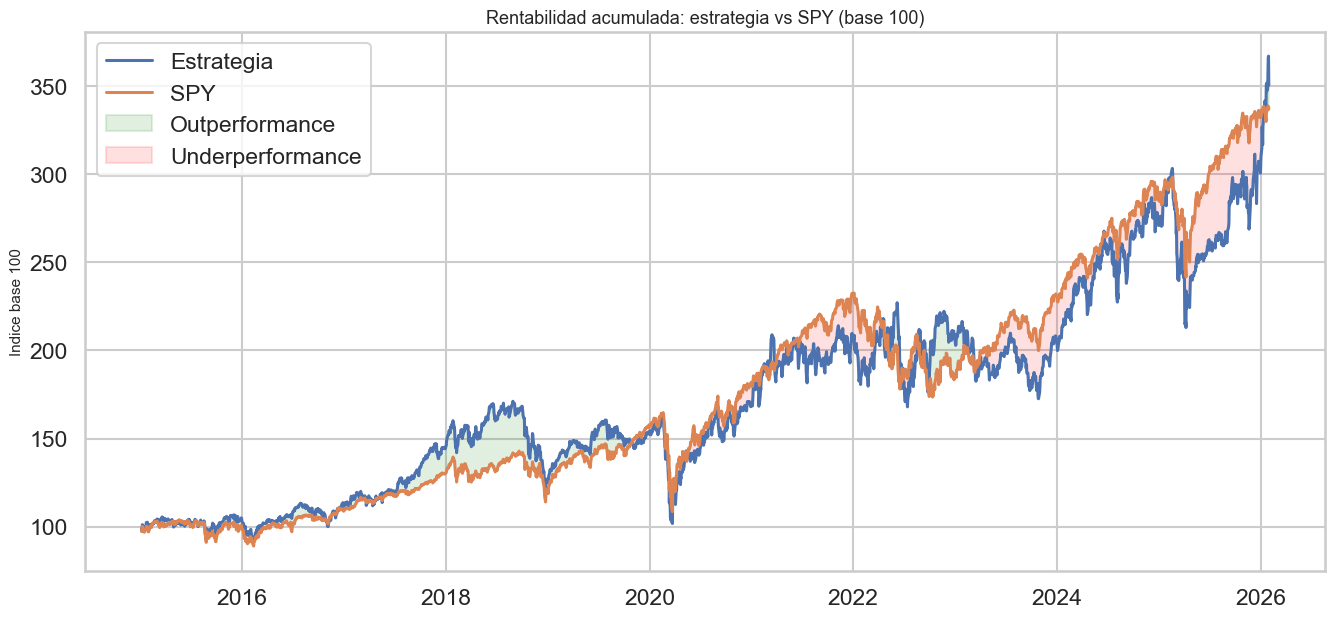

In [8]:
cum_index = (1 + returns_daily).cumprod() * 100
spread = cum_index["strategy"] - cum_index["spy"]

plt.figure(figsize=(16, 7))
plt.plot(cum_index.index, cum_index["strategy"], label="Estrategia", linewidth=2.2)
plt.plot(cum_index.index, cum_index["spy"], label="SPY", linewidth=2.2)

plt.fill_between(cum_index.index, cum_index["strategy"], cum_index["spy"], where=spread >= 0, color="green", alpha=0.12, label="Outperformance")
plt.fill_between(cum_index.index, cum_index["strategy"], cum_index["spy"], where=spread < 0, color="red", alpha=0.12, label="Underperformance")

plt.title("Rentabilidad acumulada: estrategia vs SPY (base 100)")
plt.ylabel("Indice base 100")
plt.legend(loc="upper left")
plt.show()

### Interpretacion curva acumulada

La curva muestra la trayectoria relativa estrategia-SPY y el sombreado separa fases de ventaja y desventaja. El resultado clave es identificar en qu? reg?menes se construye el resultado final. La lectura ?til es temporal: no basta con el punto final, importa c?mo se lleg?. La limitaci?n es que la curva por s? sola no descompone impacto de costes o no-fills.


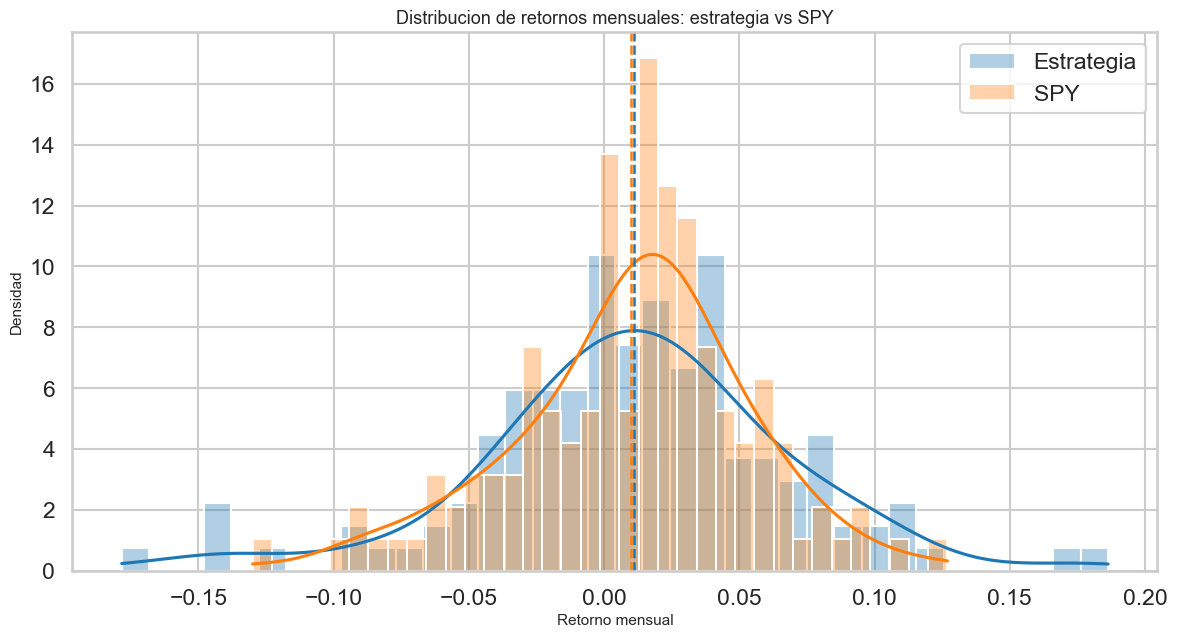

In [9]:
plt.figure(figsize=(14, 7))
sns.histplot(monthly_returns["strategy"], bins=36, stat="density", color="tab:blue", alpha=0.35, kde=True, label="Estrategia")
sns.histplot(monthly_returns["spy"], bins=36, stat="density", color="tab:orange", alpha=0.35, kde=True, label="SPY")
plt.axvline(monthly_returns["strategy"].mean(), color="tab:blue", linestyle="--", linewidth=1.8)
plt.axvline(monthly_returns["spy"].mean(), color="tab:orange", linestyle="--", linewidth=1.8)
plt.title("Distribucion de retornos mensuales: estrategia vs SPY")
plt.xlabel("Retorno mensual")
plt.ylabel("Densidad")
plt.legend()
plt.show()

### Interpretacion del histograma mensual

La distribuci?n mensual compara centro, dispersi?n y colas entre estrategia y benchmark. El resultado clave es visualizar asimetr?as y extremos con bins y KDE. La lectura es entender si el perfil de riesgo est? concentrado en pocos meses o es m?s estable. La limitaci?n es que al agregar a mensual se pierde informaci?n de secuencia diaria.


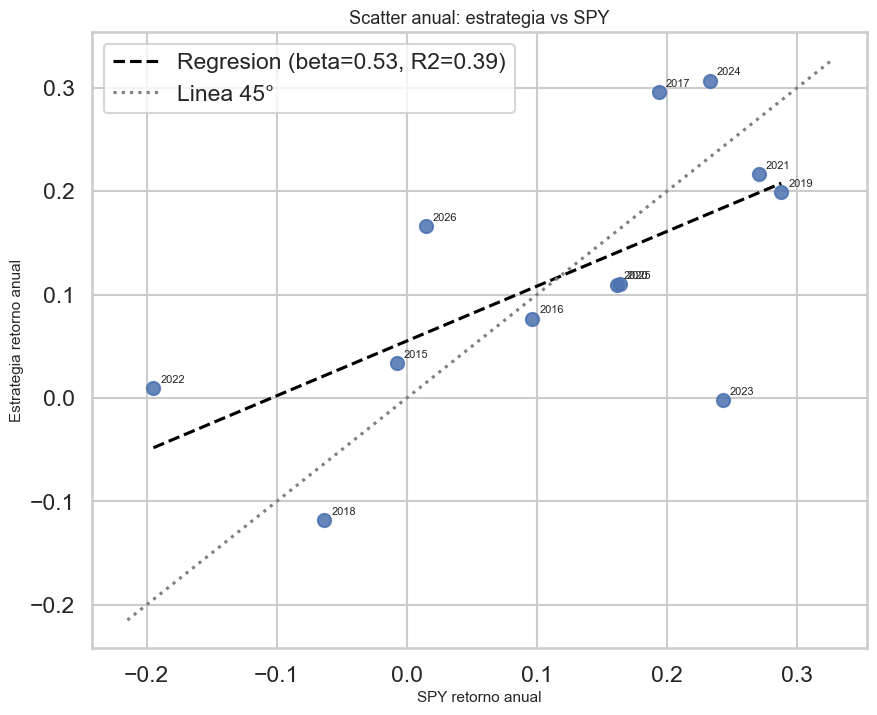

In [10]:
annual_scatter = annual_returns.dropna().copy()
annual_scatter["year"] = annual_scatter.index.year

x = annual_scatter["spy"].to_numpy()
y = annual_scatter["strategy"].to_numpy()
reg = stats.linregress(x, y)
r2 = reg.rvalue ** 2

plt.figure(figsize=(10, 8))
plt.scatter(x, y, s=90, alpha=0.85)
plt.plot(np.sort(x), reg.intercept + reg.slope * np.sort(x), color="black", linestyle="--", label=f"Regresion (beta={reg.slope:.2f}, R2={r2:.2f})")
lims = [min(x.min(), y.min()) - 0.02, max(x.max(), y.max()) + 0.02]
plt.plot(lims, lims, color="gray", linestyle=":", label="Linea 45°")

for _, row in annual_scatter.iterrows():
    plt.annotate(str(int(row["year"])), (row["spy"], row["strategy"]), textcoords="offset points", xytext=(5, 4), fontsize=8)

plt.title("Scatter anual: estrategia vs SPY")
plt.xlabel("SPY retorno anual")
plt.ylabel("Estrategia retorno anual")
plt.legend()
plt.show()

### Interpretacion scatter anual

El scatter anual resume consistencia relativa por ejercicio frente a SPY. El resultado clave es la combinaci?n de pendiente, R? y posici?n respecto a la l?nea de 45 grados. La lectura es si la ventaja aparece de forma recurrente o depende de pocos a?os. La limitaci?n es que el tama?o muestral anual suele ser reducido.


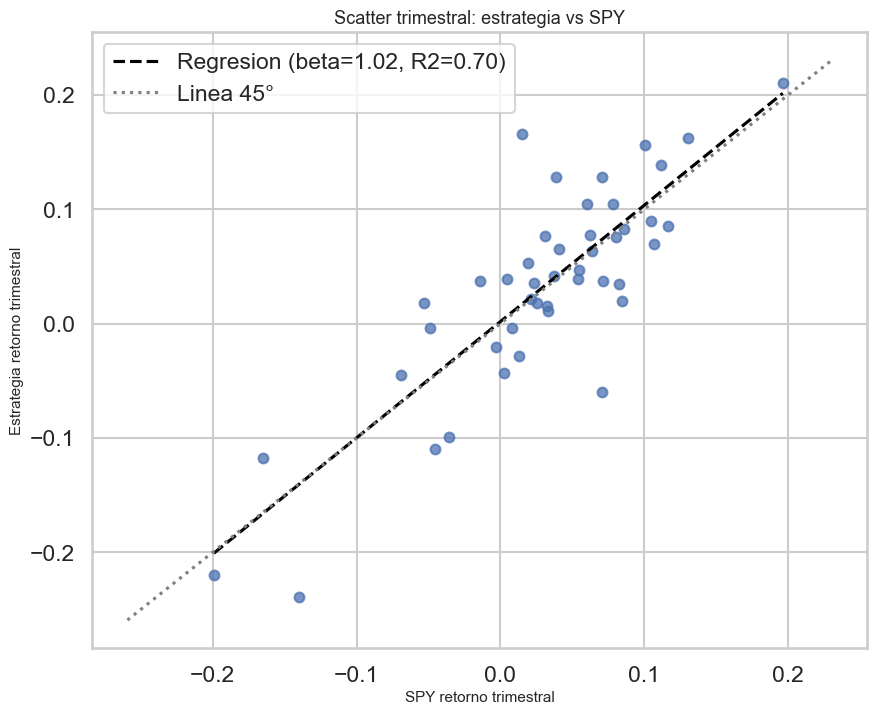

In [11]:
quarter_scatter = quarterly_returns.dropna().copy()
x = quarter_scatter["spy"].to_numpy()
y = quarter_scatter["strategy"].to_numpy()
reg_q = stats.linregress(x, y)
r2_q = reg_q.rvalue ** 2

plt.figure(figsize=(10, 8))
plt.scatter(x, y, s=50, alpha=0.75)
plt.plot(np.sort(x), reg_q.intercept + reg_q.slope * np.sort(x), color="black", linestyle="--", label=f"Regresion (beta={reg_q.slope:.2f}, R2={r2_q:.2f})")
lims = [min(x.min(), y.min()) - 0.02, max(x.max(), y.max()) + 0.02]
plt.plot(lims, lims, color="gray", linestyle=":", label="Linea 45°")
plt.title("Scatter trimestral: estrategia vs SPY")
plt.xlabel("SPY retorno trimestral")
plt.ylabel("Estrategia retorno trimestral")
plt.legend()
plt.show()

### Interpretacion scatter trimestral

El scatter trimestral aumenta granularidad para evaluar estabilidad intra-anual. El resultado clave es una lectura m?s fina de dispersi?n y dependencia con el benchmark. La lectura es comprobar si la consistencia anual se sostiene en tramos m?s cortos. La limitaci?n es que los trimestres no son observaciones completamente independientes.


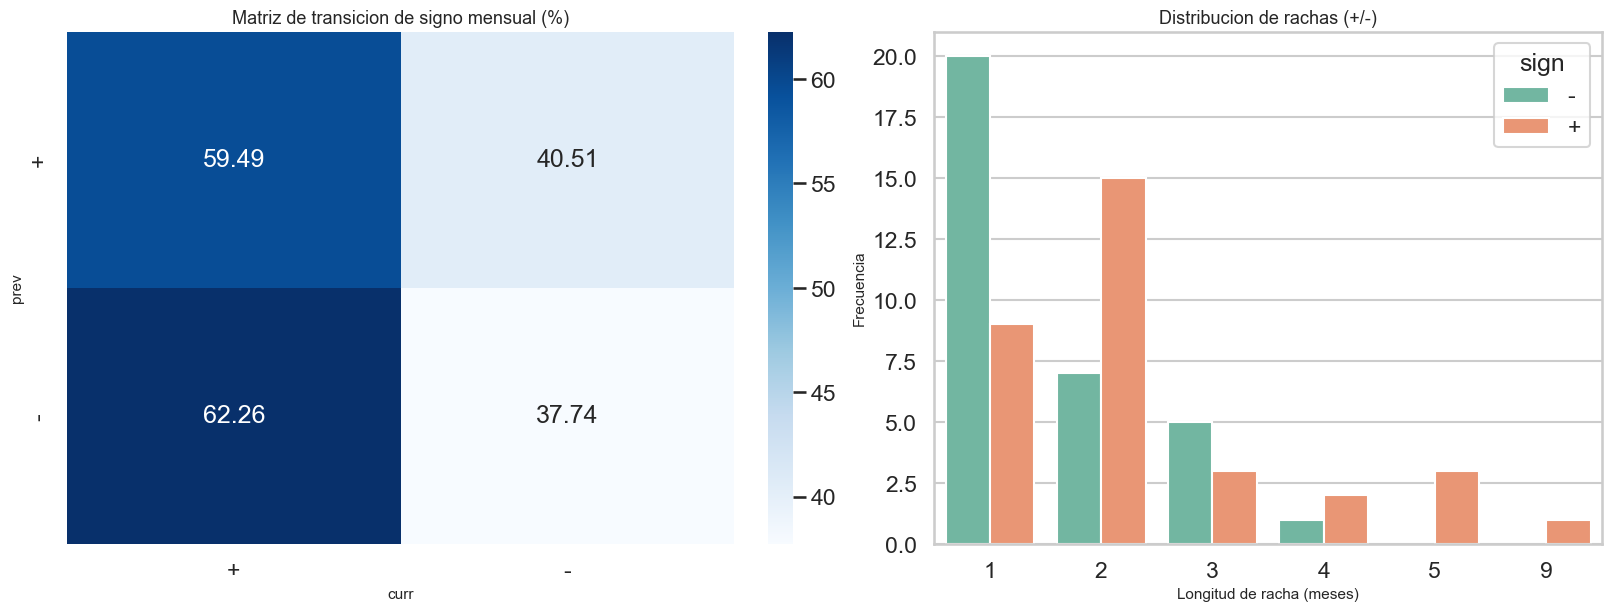

curr,+,-
prev,,
+,59.493671,40.506329
-,62.264151,37.735849


In [12]:
monthly_sign = np.where(monthly_returns["strategy"] >= 0, "+", "-")
trans_df = pd.DataFrame({"prev": pd.Series(monthly_sign).shift(1), "curr": monthly_sign}).dropna()
transition = pd.crosstab(trans_df["prev"], trans_df["curr"], normalize="index") * 100

sign_series = pd.Series(monthly_sign, index=monthly_returns.index)
groups = (sign_series != sign_series.shift(1)).cumsum()
streak_len = sign_series.groupby(groups).size()
streak_sign = sign_series.groupby(groups).first()
streak_df = pd.DataFrame({"sign": streak_sign.values, "length": streak_len.values})

fig, axes = plt.subplots(1, 2, figsize=(16, 6), constrained_layout=True)
sns.heatmap(transition, annot=True, fmt=".2f", cmap="Blues", ax=axes[0])
axes[0].set_title("Matriz de transicion de signo mensual (%)")

sns.countplot(data=streak_df, x="length", hue="sign", ax=axes[1], palette="Set2")
axes[1].set_title("Distribucion de rachas (+/-)")
axes[1].set_xlabel("Longitud de racha (meses)")
axes[1].set_ylabel("Frecuencia")
plt.show()

display(transition)


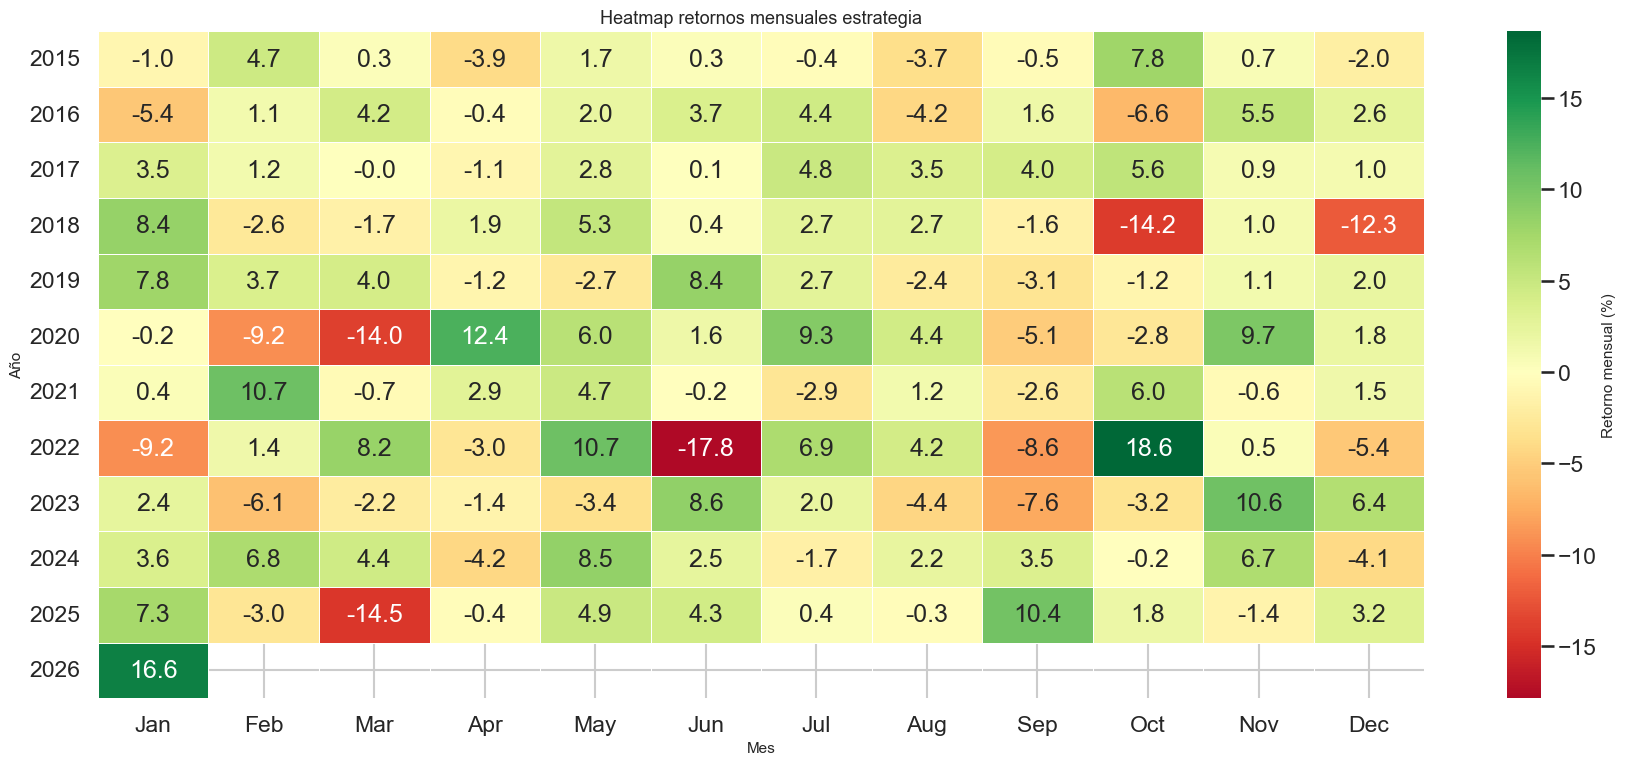

In [13]:
heat = monthly_returns["strategy"].copy() * 100
heat_df = pd.DataFrame(
    {
        "year": heat.index.year,
        "month": heat.index.month,
        "value": heat.values,
    }
)
heat_pivot = heat_df.pivot(index="year", columns="month", values="value")
month_labels = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
heat_pivot = heat_pivot.reindex(columns=range(1, 13))

plt.figure(figsize=(18, 8))
sns.heatmap(heat_pivot, cmap="RdYlGn", center=0, annot=True, fmt=".1f", linewidths=0.4, cbar_kws={"label": "Retorno mensual (%)"})
plt.title("Heatmap retornos mensuales estrategia")
plt.xlabel("Mes")
plt.ylabel("Año")
plt.xticks(np.arange(12) + 0.5, month_labels, rotation=0)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### Interpretacion de recurrencia

La matriz de transici?n y las rachas capturan persistencia de meses positivos y negativos. El resultado clave es identificar si existe inercia de r?gimen. La lectura es contextualizar el rendimiento en t?rminos de secuencia, no solo de media. La limitaci?n es que trabajar con signo reduce informaci?n de magnitud.


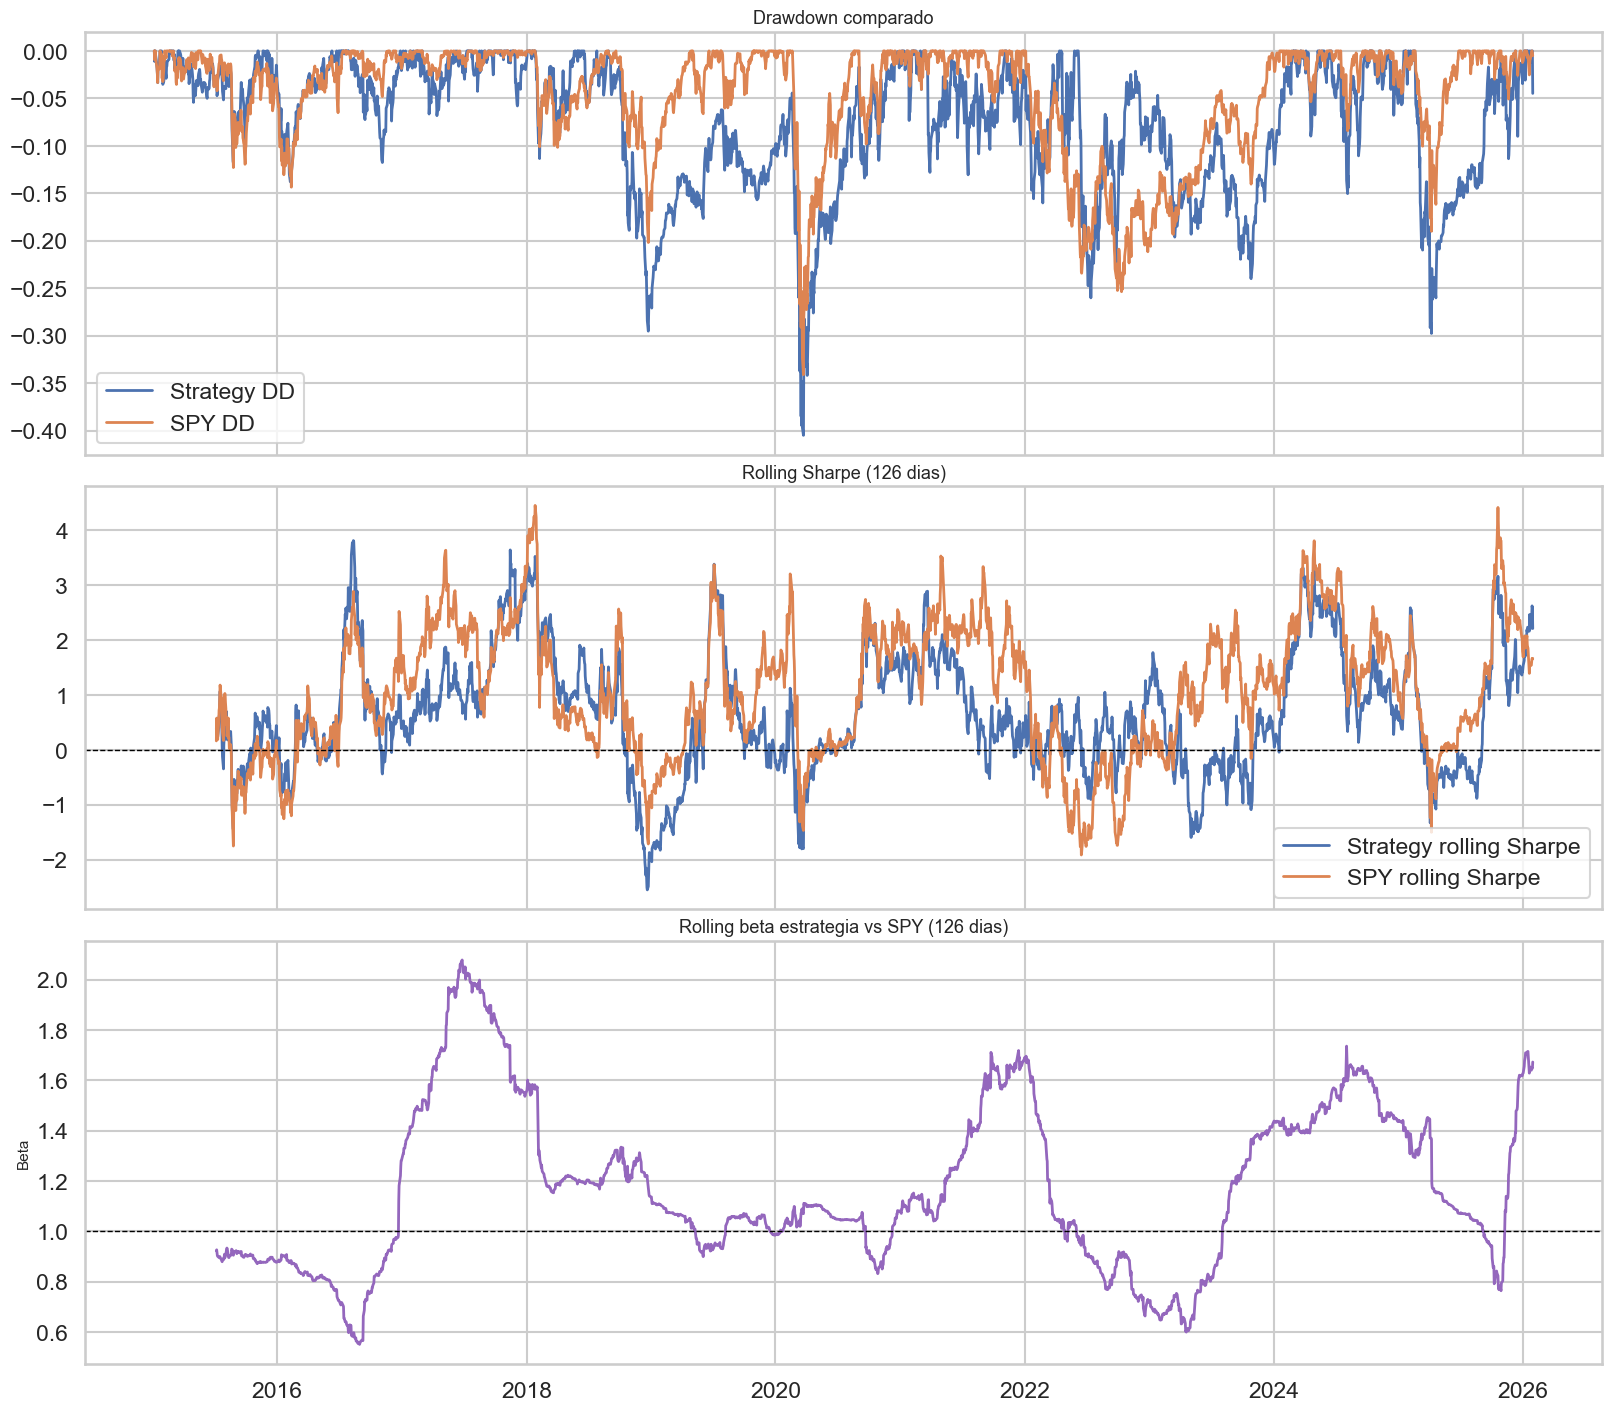

In [14]:
wealth_curve = (1 + returns_daily).cumprod()
drawdown = wealth_curve / wealth_curve.cummax() - 1

win = 126
roll_mean = returns_daily.rolling(win).mean()
roll_std = returns_daily.rolling(win).std(ddof=1)
rolling_sharpe = np.sqrt(TRADING_DAYS) * ((roll_mean - RF_DAILY) / roll_std)

rolling_beta = (
    returns_daily["strategy"].rolling(win).cov(returns_daily["spy"]) /
    returns_daily["spy"].rolling(win).var()
)

fig, axes = plt.subplots(3, 1, figsize=(16, 14), sharex=True, constrained_layout=True)

axes[0].plot(drawdown.index, drawdown["strategy"], label="Strategy DD", linewidth=2)
axes[0].plot(drawdown.index, drawdown["spy"], label="SPY DD", linewidth=2)
axes[0].set_title("Drawdown comparado")
axes[0].legend()

axes[1].plot(rolling_sharpe.index, rolling_sharpe["strategy"], label="Strategy rolling Sharpe", linewidth=2)
axes[1].plot(rolling_sharpe.index, rolling_sharpe["spy"], label="SPY rolling Sharpe", linewidth=2)
axes[1].axhline(0, color="black", linestyle="--", linewidth=1)
axes[1].set_title("Rolling Sharpe (126 dias)")
axes[1].legend()

axes[2].plot(rolling_beta.index, rolling_beta, color="tab:purple", linewidth=2)
axes[2].axhline(1, color="black", linestyle="--", linewidth=1)
axes[2].set_title("Rolling beta estrategia vs SPY (126 dias)")
axes[2].set_ylabel("Beta")

plt.show()

### Interpretacion de riesgo dinamico

Drawdown, rolling Sharpe y rolling Beta permiten seguir el riesgo en el tiempo. El resultado clave es separar profundidad de ca?das, eficiencia riesgo-ajustada y exposici?n al mercado. La lectura es cu?ndo la estrategia gana con mayor fragilidad. La limitaci?n es que toda m?trica rolling es sensible al tama?o de ventana.


### Objetivo: diagnostico operativo (fricciones reales)

Se cuantifica c?mo `no_fill_cash`, tensi?n de caja, salidas con proxy y pol?tica de rebalanceo afectan resultado econ?mico neto, no solo el retorno bruto.


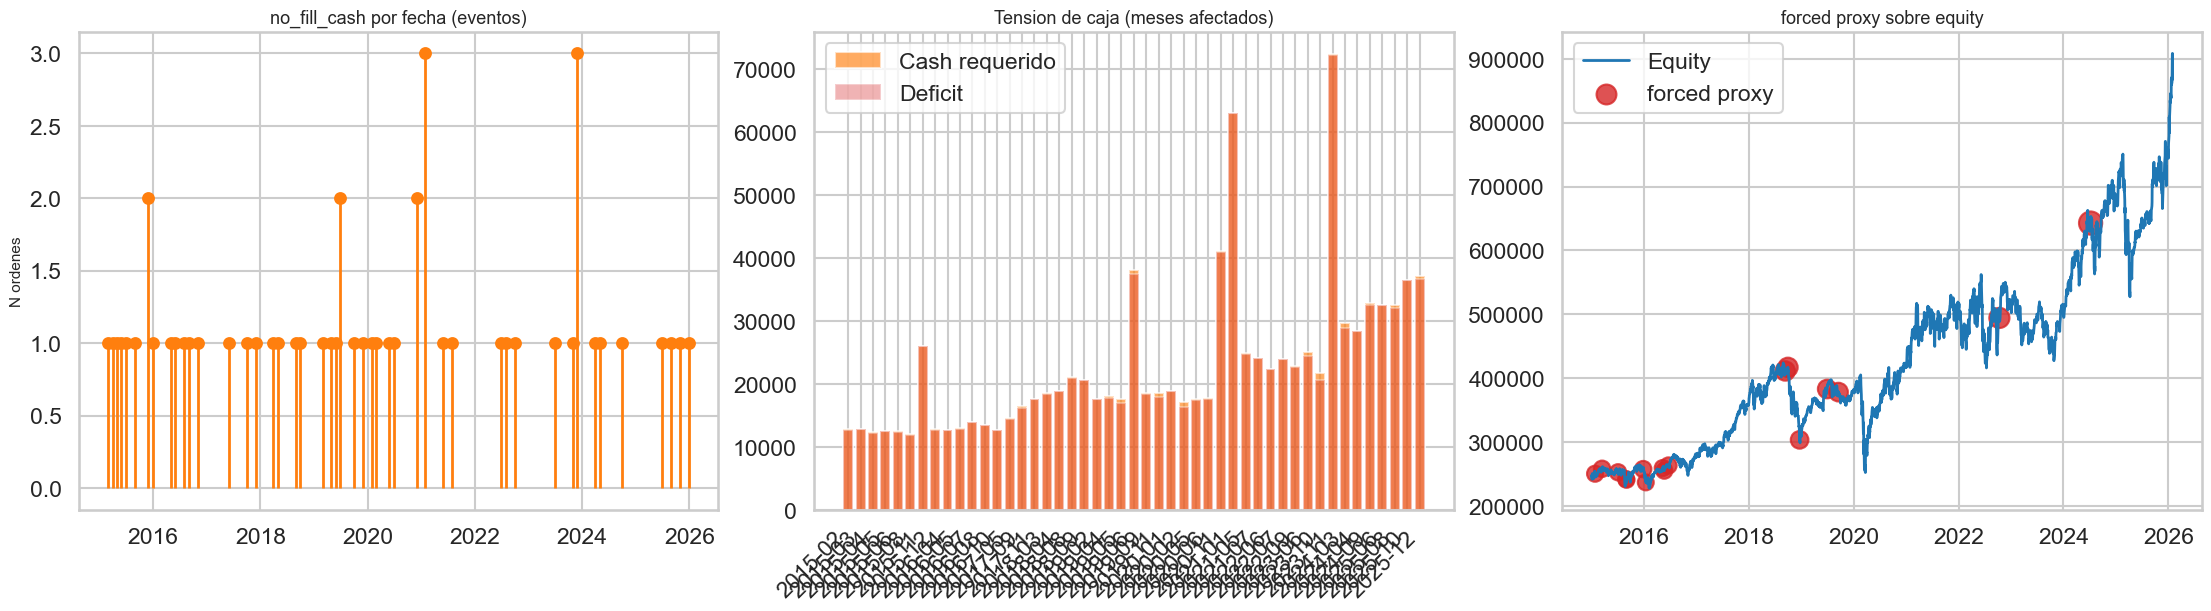

In [15]:
no_fill_cash_df = orders.loc[
    orders["status"] == "no_fill_cash",
    ["date", "symbol", "reason", "price", "cash_after", "policy_mode"],
].copy().sort_values(["date", "symbol"])
no_fill_by_date = no_fill_cash_df.groupby("date").size().rename("count")

reb = rebalance_summary.copy().sort_values("date")
if "n_rebalance_entry_no_fill_cash" not in reb.columns:
    reb["n_rebalance_entry_no_fill_cash"] = 0
reb["required_cash_proxy"] = reb["equity"] * 0.05 * reb["n_rebalance_entry_no_fill_cash"]
reb["deficit_proxy"] = np.clip(reb["required_cash_proxy"] - reb["cash"], 0, None)
reb_tension = reb.loc[reb["n_rebalance_entry_no_fill_cash"] > 0].copy()

forced_proxy_df = orders.loc[
    (orders["reason"] == "forced_exit_no_quote_proxy") & (orders["status"] == "filled"),
    ["date", "symbol", "price", "fee", "proxy_price_date", "policy_mode"],
].copy().sort_values(["date", "symbol"])

fig, axes = plt.subplots(1, 3, figsize=(22, 6), constrained_layout=True)
ax = axes[0]
if len(no_fill_by_date) > 0:
    ax.vlines(no_fill_by_date.index, 0, no_fill_by_date.values, color="tab:orange", linewidth=2)
    ax.scatter(no_fill_by_date.index, no_fill_by_date.values, color="tab:orange", s=60)
ax.set_title("no_fill_cash por fecha (eventos)")
ax.set_ylabel("N ordenes")

ax = axes[1]
if len(reb_tension) > 0:
    x = np.arange(len(reb_tension))
    labels = reb_tension["date"].dt.strftime("%Y-%m")
    ax.bar(x, reb_tension["required_cash_proxy"], color="tab:orange", alpha=0.65, label="Cash requerido")
    ax.bar(x, reb_tension["deficit_proxy"], color="tab:red", alpha=0.35, label="Deficit")
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=45, ha="right")
    ax.legend(loc="upper left")
ax.set_title("Tension de caja (meses afectados)")

ax = axes[2]
ax.plot(portfolio_daily["date"], portfolio_daily["equity"], color="tab:blue", linewidth=2, label="Equity")
if len(forced_proxy_df) > 0:
    forced_plot = forced_proxy_df.groupby("date", as_index=False)["fee"].sum()
    eq_map = portfolio_daily.set_index("date")["equity"]
    yvals = forced_plot["date"].map(eq_map)
    sizes = 40 + (forced_plot["fee"] / forced_plot["fee"].max() * 240)
    ax.scatter(forced_plot["date"], yvals, color="tab:red", s=sizes, alpha=0.8, label="forced proxy")
ax.set_title("forced proxy sobre equity")
ax.legend(loc="upper left")

plt.show()

In [16]:
policy_tradeoff = n4_checks.loc[
    n4_checks["check"] == "policy_reweight_tradeoff_documented",
    "details",
]
fail_if(len(policy_tradeoff) == 0, "No existe check policy_reweight_tradeoff_documented en n4_checks.csv")
tradeoff_text = policy_tradeoff.iloc[0]

m_fee = re.search(r"delta_fee=([-+]?\d*\.?\d+)", tradeoff_text)
m_eq = re.search(r"delta_final_equity=([-+]?\d*\.?\d+)", tradeoff_text)
m_nofill = re.search(r"delta_no_fill_cash=([-+]?\d+)", tradeoff_text)
fail_if(m_fee is None or m_eq is None or m_nofill is None, f"No se pudieron parsear deltas: {tradeoff_text}")

delta_fee = float(m_fee.group(1))
delta_eq = float(m_eq.group(1))
delta_nofill = int(m_nofill.group(1))

with_cost = cost_summary.iloc[0]
policy_kpis = pd.DataFrame(
    [
        {
            "policy_mode": "with_reweight",
            "final_equity": float(with_cost["final_equity"]),
            "total_fee": float(with_cost["total_fee"]),
            "n_no_fill_cash": int(float(with_cost["n_no_fill_cash"])),
        },
        {
            "policy_mode": "without_reweight",
            "final_equity": float(with_cost["final_equity"] - delta_eq),
            "total_fee": float(with_cost["total_fee"] - delta_fee),
            "n_no_fill_cash": int(float(with_cost["n_no_fill_cash"]) - delta_nofill),
        },
    ]
)

display(policy_kpis)

,policy_mode,final_equity,total_fee,n_no_fill_cash
0,with_reweight,8.679769e+05,134949.42769,54
1,without_reweight,1.242900e+06,111964.19799,93


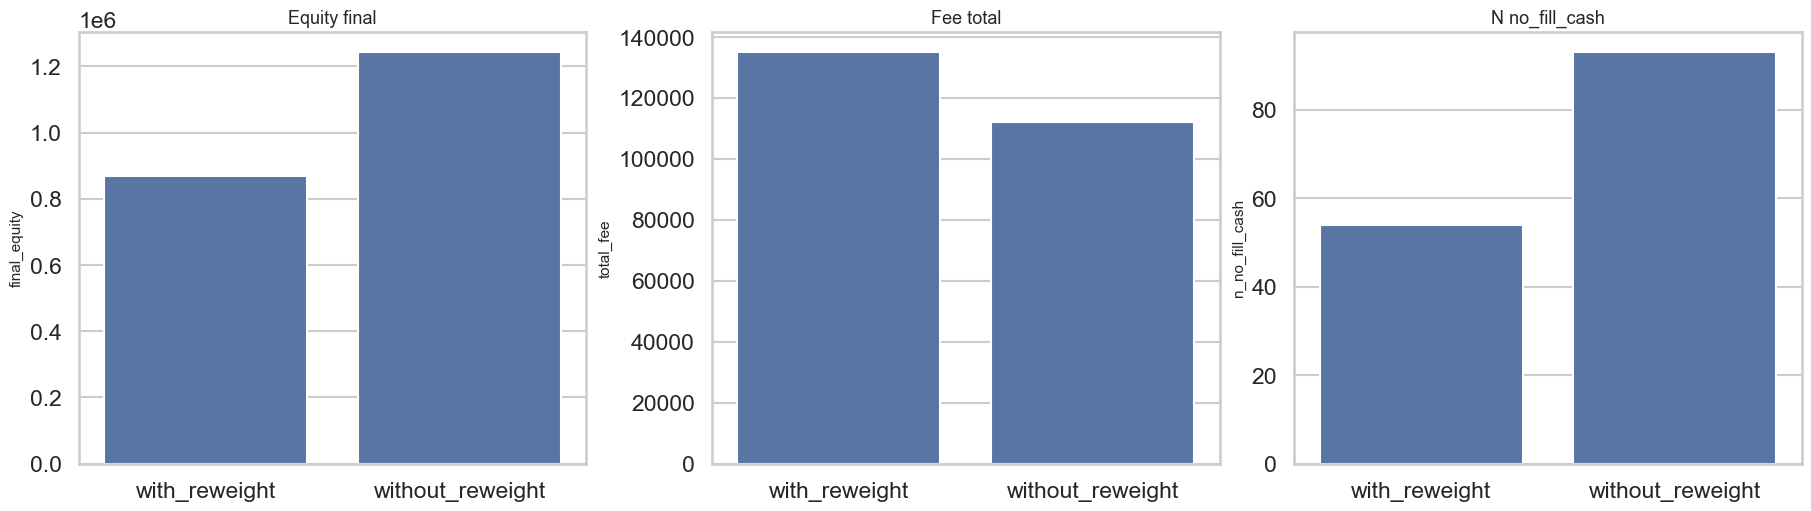

,no_fill_cash_orders,no_fill_cash_dates,forced_proxy_cases,forced_proxy_fee_total
0,54,47,17,643.784901


In [17]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)
for ax, col, title in zip(
    axes,
    ["final_equity", "total_fee", "n_no_fill_cash"],
    ["Equity final", "Fee total", "N no_fill_cash"],
):
    sns.barplot(data=policy_kpis, x="policy_mode", y=col, ax=ax)
    ax.set_title(title)
    ax.set_xlabel("")

plt.show()

operational_summary = pd.DataFrame(
    [
        {
            "no_fill_cash_orders": int(len(no_fill_cash_df)),
            "no_fill_cash_dates": int(no_fill_cash_df["date"].nunique()),
            "forced_proxy_cases": int(len(forced_proxy_df)),
            "forced_proxy_fee_total": float(forced_proxy_df["fee"].sum()),
        }
    ]
)
display(operational_summary)


### Interpretacion operativa y de costes

Esta secci?n traduce fricciones operativas a impacto econ?mico medible. El resultado clave es el trade-off entre pol?ticas y el peso real de comisiones y m?nimos por orden. La lectura es que el desempe?o s?lo es defendible tras descontar ejecuci?n realista. La limitaci?n es que el contraste usa agregados hist?ricos, no replay microestructural intrad?a.


### Objetivo: comisiones con contexto fuerte

Se presentan comisiones en t?rminos absolutos y relativos para evaluar si el coste es marginal o estructural en la explicaci?n del resultado final.


In [18]:
filled_orders = orders.loc[orders["status"] == "filled"].copy()
filled_orders = filled_orders.loc[filled_orders["notional"].abs() > 0].copy()

filled_orders["fee_prop"] = filled_orders["notional"].abs() * fee_rate
filled_orders["fee_model"] = np.maximum(filled_orders["fee_prop"], fee_min)
filled_orders["min_fee_hit"] = filled_orders["fee_prop"] < fee_min
filled_orders["extra_due_to_min"] = np.where(
    filled_orders["min_fee_hit"],
    fee_min - filled_orders["fee_prop"],
    0.0,
)

n_min_hit = int(filled_orders["min_fee_hit"].sum())
extra_min_total = float(filled_orders["extra_due_to_min"].sum())

total_fee = float(cost_summary["total_fee"].iloc[0])
initial_capital = float(cost_summary["initial_capital"].iloc[0])
final_equity = float(cost_summary["final_equity"].iloc[0])

commission_context = pd.DataFrame(
    [
        {"metric": "Total fee (USD)", "value": total_fee},
        {"metric": "Fee / Initial capital (%)", "value": 100 * total_fee / initial_capital},
        {"metric": "Fee / Final equity (%)", "value": 100 * total_fee / final_equity},
        {"metric": "Buy fee (USD)", "value": float(cost_summary["buy_fee"].iloc[0])},
        {"metric": "Sell fee (USD)", "value": float(cost_summary["sell_fee"].iloc[0])},
        {"metric": "Forced exit proxy fee (USD)", "value": float(cost_summary["forced_exit_proxy_fee"].iloc[0])},
        {"metric": "Orders impacted by minimum fee", "value": n_min_hit},
        {"metric": "Extra fee due to minimum (USD)", "value": extra_min_total},
    ]
)

display(commission_context)

,metric,value
0,Total fee (USD),134949.427690
1,Fee / Initial capital (%),53.979771
2,Fee / Final equity (%),15.547582
3,Buy fee (USD),68104.784178
4,Sell fee (USD),66844.643511
5,Forced exit proxy fee (USD),643.784901
6,Orders impacted by minimum fee,1535.000000
7,Extra fee due to minimum (USD),30512.819799


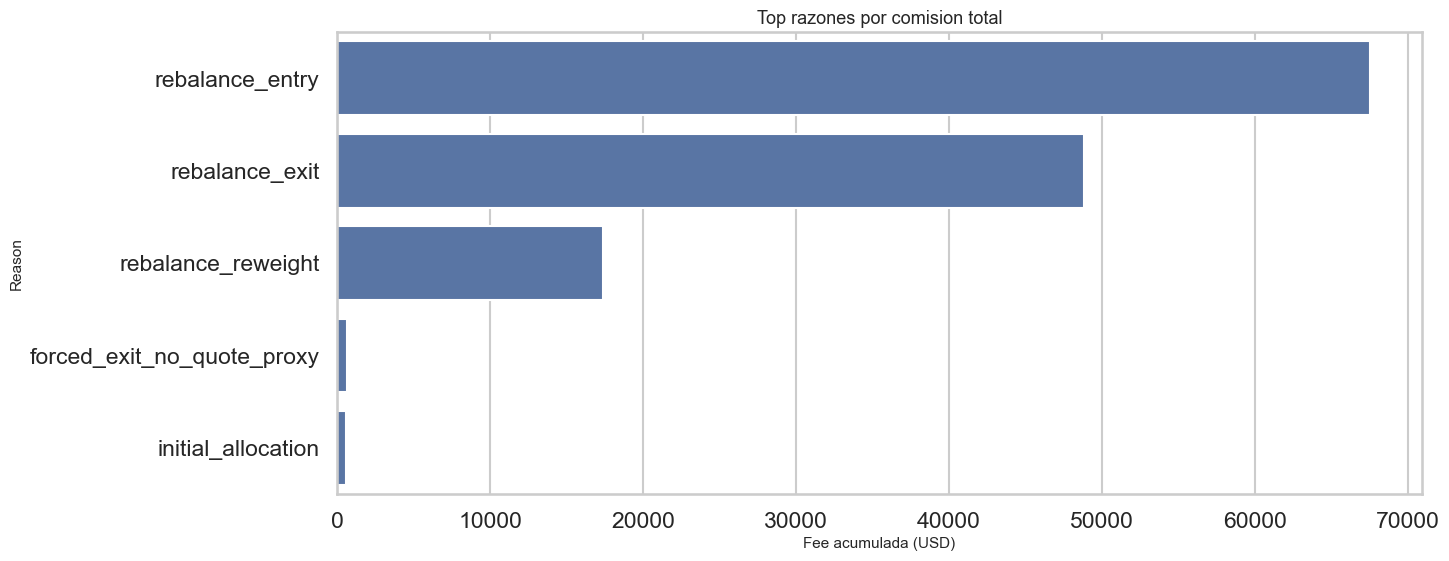

In [19]:
fee_reason = (
    filled_orders.groupby("reason", as_index=False)["fee"]
    .sum()
    .sort_values("fee", ascending=False)
    .head(10)
)

plt.figure(figsize=(14, 6))
sns.barplot(data=fee_reason, x="fee", y="reason", orient="h")
plt.title("Top razones por comision total")
plt.xlabel("Fee acumulada (USD)")
plt.ylabel("Reason")
plt.show()

### Objetivo: Monte Carlo principal (directo, no parametrico)

El bloque aplica la metodolog?a principal del enunciado con par?metros fijos (`25M` monos, `20` activos, semilla `42`, coste mensual `0.46%`). Cada mes se muestrean carteras sin reemplazo sobre retornos forward reales y se acumula riqueza final por lotes, registrando tiempo total para validar el requisito de ejecuci?n menor a 24 horas.


In [20]:
strategy_final_equity = float(cost_summary["final_equity"].iloc[0])
initial_capital = float(cost_summary["initial_capital"].iloc[0])

signals_mc = signals_input[["rebalance_date", "symbol", "eligible_for_signals", "close_rebalance"]].copy()
signals_mc["rebalance_date"] = pd.to_datetime(signals_mc["rebalance_date"])
signals_mc = signals_mc.sort_values(["symbol", "rebalance_date"]).reset_index(drop=True)

signals_mc["close_next"] = signals_mc.groupby("symbol", observed=True)["close_rebalance"].shift(-1)
signals_mc["fwd_monthly_return"] = signals_mc["close_next"] / signals_mc["close_rebalance"] - 1

signal_months = rebalance_summary["date"].drop_duplicates().sort_values()
mc_universe = signals_mc.loc[
    (signals_mc["rebalance_date"].isin(signal_months))
    & (signals_mc["eligible_for_signals"] == True)
    & np.isfinite(signals_mc["fwd_monthly_return"])
    & (signals_mc["fwd_monthly_return"] > -0.999),
    ["rebalance_date", "symbol", "fwd_monthly_return"],
].copy()

month_groups = []
for dt, grp in mc_universe.groupby("rebalance_date", observed=True):
    arr = grp["fwd_monthly_return"].to_numpy(dtype=np.float32)
    if len(arr) >= MONKEY_PORTFOLIO_SIZE:
        month_groups.append((pd.Timestamp(dt), arr))

fail_if(len(month_groups) == 0, "No hay meses validos para Monte Carlo directo")
batches_per_month = int(np.ceil(N_MONKEYS / MONKEY_BATCH_SIZE))

mc_scope = pd.DataFrame(
    [
        {
            "valid_months": int(len(month_groups)),
            "batches_per_month": int(batches_per_month),
            "n_monkeys": int(N_MONKEYS),
            "portfolio_size": int(MONKEY_PORTFOLIO_SIZE),
        }
    ]
)
display(mc_scope)


,valid_months,batches_per_month,n_monkeys,portfolio_size
0,132,100,25000000,20


In [21]:
rng = np.random.default_rng(MONKEY_SEED)
log_growth = np.zeros(N_MONKEYS, dtype=np.float32)

mc_start_utc = pd.Timestamp.now(tz="UTC")
t0 = time.perf_counter()

for m_idx, (month_dt, month_ret_arr) in enumerate(month_groups, start=1):
    n_assets = month_ret_arr.size
    start = 0
    while start < N_MONKEYS:
        batch = min(MONKEY_BATCH_SIZE, N_MONKEYS - start)
        idx = sample_without_replacement_rows(
            rng=rng,
            n_rows=batch,
            n_assets=n_assets,
            k=MONKEY_PORTFOLIO_SIZE,
        )
        sampled_ret = month_ret_arr[idx].mean(axis=1, dtype=np.float32) - MONKEY_MONTHLY_COST
        sampled_ret = np.clip(sampled_ret, -0.95, None)
        log_growth[start:start + batch] += np.log1p(sampled_ret).astype(np.float32)
        start += batch

    if m_idx == 1 or m_idx % 12 == 0 or m_idx == len(month_groups):
        elapsed = time.perf_counter() - t0
        eta_min = ((elapsed / m_idx) * (len(month_groups) - m_idx)) / 60 if m_idx > 0 else np.nan
        print(
            f"Mes {m_idx:03d}/{len(month_groups)} | fecha={month_dt.date()} | "
            f"elapsed={elapsed/60:.2f} min | ETA={eta_min:.2f} min"
        )

direct_elapsed = time.perf_counter() - t0
mc_end_utc = pd.Timestamp.now(tz="UTC")
monkey_direct_wealth = (initial_capital * np.exp(log_growth.astype(np.float64))).astype(np.float32)


Mes 001/132 | fecha=2015-01-30 | elapsed=0.47 min | ETA=61.20 min
Mes 012/132 | fecha=2015-12-31 | elapsed=5.72 min | ETA=57.24 min
Mes 024/132 | fecha=2016-12-30 | elapsed=11.60 min | ETA=52.20 min
Mes 036/132 | fecha=2017-12-29 | elapsed=17.71 min | ETA=47.23 min
Mes 048/132 | fecha=2018-12-31 | elapsed=23.72 min | ETA=41.51 min
Mes 060/132 | fecha=2019-12-31 | elapsed=29.66 min | ETA=35.59 min
Mes 072/132 | fecha=2020-12-31 | elapsed=35.49 min | ETA=29.57 min
Mes 084/132 | fecha=2021-12-31 | elapsed=41.18 min | ETA=23.53 min
Mes 096/132 | fecha=2022-12-30 | elapsed=47.02 min | ETA=17.63 min
Mes 108/132 | fecha=2023-12-29 | elapsed=52.81 min | ETA=11.73 min
Mes 120/132 | fecha=2024-12-31 | elapsed=58.56 min | ETA=5.86 min
Mes 132/132 | fecha=2025-12-31 | elapsed=64.28 min | ETA=0.00 min


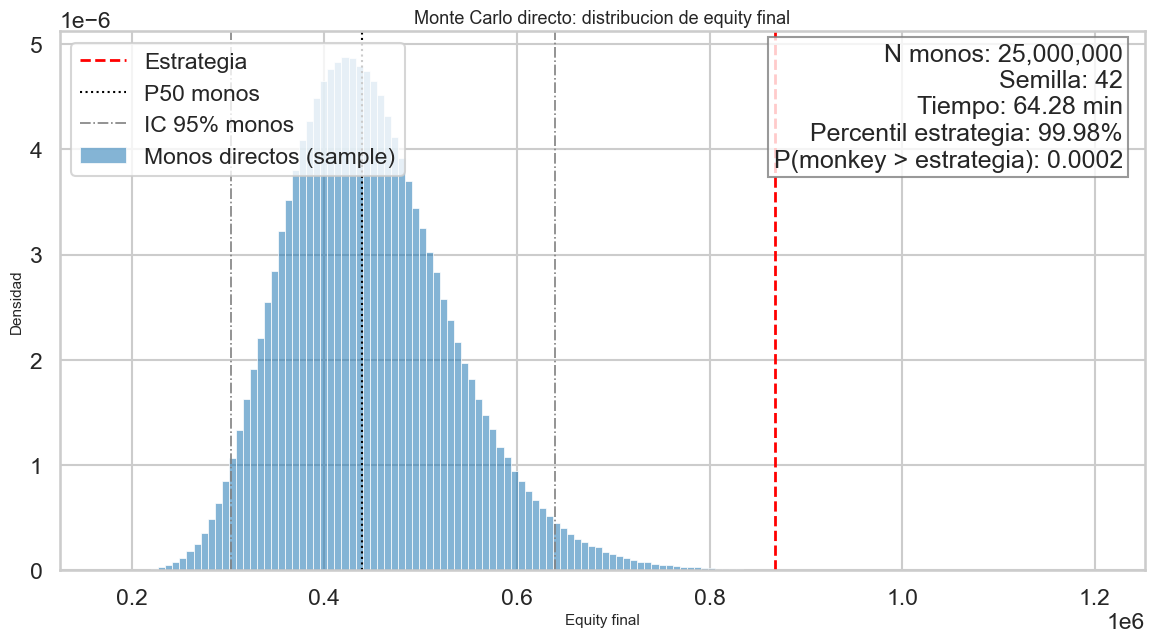

,mc_start_utc,mc_end_utc,n_monkeys,months_per_monkey,elapsed_minutes,requirement_lt_24h,strategy_percentile,p_monkey_beats_strategy,p05,p50,p95,ci95_low,ci95_high
0,2026-02-25 07:52:17.489883+00:00,2026-02-25 08:56:34.022092+00:00,25000000,132,64.275534,PASS,99.978028,0.00022,321917.0625,439172.296875,601367.625,303403.84375,639080.4375


,mc_start_utc,mc_end_utc,n_monkeys,months_per_monkey,elapsed_minutes,requirement_lt_24h,strategy_percentile,p_monkey_beats_strategy,p05,p50,p95,ci95_low,ci95_high
0,2026-02-25 07:52:17.489883+00:00,2026-02-25 08:56:34.022092+00:00,25000000,132,64.275534,PASS,99.978028,0.00022,321917.0625,439172.296875,601367.625,303403.84375,639080.4375


In [22]:
p_strategy_direct = float((monkey_direct_wealth <= strategy_final_equity).mean() * 100)
p_monkey_beats_direct = float((monkey_direct_wealth > strategy_final_equity).mean())
p05_d, p50_d, p95_d = np.percentile(monkey_direct_wealth, [5, 50, 95])
ci_low_d, ci_high_d = np.percentile(monkey_direct_wealth, [2.5, 97.5])

plot_n = min(MONKEY_PLOT_SAMPLE_N, len(monkey_direct_wealth))
plot_idx = rng.integers(0, len(monkey_direct_wealth), size=plot_n)
plot_sample_direct = monkey_direct_wealth[plot_idx]

plt.figure(figsize=(14, 7))
sns.histplot(plot_sample_direct, bins=140, stat="density", color="tab:blue", alpha=0.55, label="Monos directos (sample)")
plt.axvline(strategy_final_equity, color="red", linestyle="--", linewidth=2.0, label="Estrategia")
plt.axvline(p50_d, color="black", linestyle=":", linewidth=1.5, label="P50 monos")
plt.axvline(ci_low_d, color="gray", linestyle="-.", linewidth=1.2, label="IC 95% monos")
plt.axvline(ci_high_d, color="gray", linestyle="-.", linewidth=1.2)

textbox = (
    f"N monos: {N_MONKEYS:,}\n"
    f"Semilla: {MONKEY_SEED}\n"
    f"Tiempo: {direct_elapsed/60:.2f} min\n"
    f"Percentil estrategia: {p_strategy_direct:.2f}%\n"
    f"P(monkey > estrategia): {p_monkey_beats_direct:.4f}"
)
plt.text(0.98, 0.98, textbox, transform=plt.gca().transAxes, ha="right", va="top", bbox=dict(facecolor="white", alpha=0.8, edgecolor="gray"))

plt.title("Monte Carlo directo: distribucion de equity final")
plt.xlabel("Equity final")
plt.ylabel("Densidad")
plt.legend(loc="upper left")
plt.show()

mc_direct_summary = pd.DataFrame([
    {
        "mc_start_utc": mc_start_utc,
        "mc_end_utc": mc_end_utc,
        "n_monkeys": int(N_MONKEYS),
        "months_per_monkey": int(len(month_groups)),
        "elapsed_minutes": float(direct_elapsed / 60),
        "requirement_lt_24h": "PASS" if direct_elapsed < 24 * 3600 else "FAIL",
        "strategy_percentile": float(p_strategy_direct),
        "p_monkey_beats_strategy": float(p_monkey_beats_direct),
        "p05": float(p05_d),
        "p50": float(p50_d),
        "p95": float(p95_d),
        "ci95_low": float(ci_low_d),
        "ci95_high": float(ci_high_d),
    }
])
display(mc_direct_summary)
mc_direct_summary = pd.DataFrame(
    [
        {
            "mc_start_utc": mc_start_utc,
            "mc_end_utc": mc_end_utc,
            "n_monkeys": int(N_MONKEYS),
            "months_per_monkey": int(len(month_groups)),
            "elapsed_minutes": float(direct_elapsed / 60),
            "requirement_lt_24h": "PASS" if direct_elapsed < 24 * 3600 else "FAIL",
            "strategy_percentile": float(p_strategy_direct),
            "p_monkey_beats_strategy": float(p_monkey_beats_direct),
            "p05": float(p05_d),
            "p50": float(p50_d),
            "p95": float(p95_d),
            "ci95_low": float(ci_low_d),
            "ci95_high": float(ci_high_d),
        }
    ]
)
display(mc_direct_summary)


### Interpretacion Monte Carlo directo

El resultado principal es el percentil de la estrategia dentro de la distribuci?n de carteras aleatorias y la probabilidad `P(monkey > estrategia)`. La lectura es una prueba de robustez bajo reglas operativas realistas y no param?tricas. La conclusi?n debe apoyarse en percentiles, IC y tiempo de c?mputo reportado. La limitaci?n es que el coste mensual es fijo y no modela fricci?n intrames.


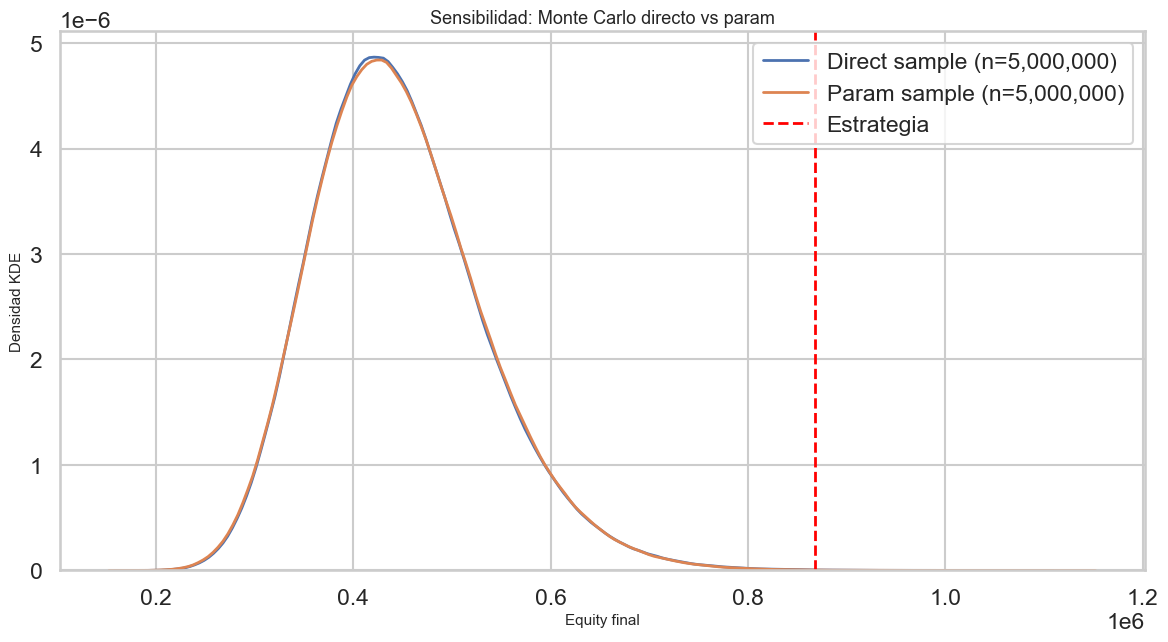

,param_elapsed_s,param_n
0,11.208061,5000000


,model,mean,p05,p50,p95,delta_vs_direct
0,direct,447448.96875,321928.34375,439154.125,601321.875,0.00000
1,param,447501.56250,321002.96875,439491.750,601134.375,52.59375


In [ ]:
param_n = min(N_MONKEYS_PARAM_SENS, N_MONKEYS)
rng_param = np.random.default_rng(MONKEY_SEED)

mu_list = []
std_list = []
for _, arr in month_groups:
    mu = float(np.mean(arr) - MONKEY_MONTHLY_COST)
    sigma = float(np.std(arr, ddof=1))
    n_assets = len(arr)
    fpc = np.sqrt(max((n_assets - MONKEY_PORTFOLIO_SIZE) / (n_assets - 1), 0.0)) if n_assets > 1 else 0.0
    std_mean = sigma / np.sqrt(MONKEY_PORTFOLIO_SIZE) * fpc
    mu_list.append(mu)analysis_window
    std_list.append(std_mean)

mu_arr = np.array(mu_list, dtype=np.float32)
std_arr = np.array(std_list, dtype=np.float32)

log_growth_param = np.zeros(param_n, dtype=np.float32)
t0 = time.perf_counter()
for m in range(len(mu_arr)):
    draws = rng_param.normal(loc=float(mu_arr[m]), scale=float(std_arr[m]), size=param_n).astype(np.float32)
    draws = np.clip(draws, -0.95, None)
    log_growth_param += np.log1p(draws).astype(np.float32)
param_elapsed = time.perf_counter() - t0

monkey_param_wealth = (initial_capital * np.exp(log_growth_param.astype(np.float64))).astype(np.float32)

direct_sample = (
    monkey_direct_wealth[rng_param.integers(0, len(monkey_direct_wealth), size=param_n)]
    if len(monkey_direct_wealth) > param_n
    else monkey_direct_wealth.astype(np.float32)
)

compare_table = pd.DataFrame(
    [
        {
            "model": "direct",
            "mean": float(np.mean(direct_sample)),
            "p05": float(np.percentile(direct_sample, 5)),
            "p50": float(np.percentile(direct_sample, 50)),
            "p95": float(np.percentile(direct_sample, 95)),
        },
        {
            "model": "param",
            "mean": float(np.mean(monkey_param_wealth)),
            "p05": float(np.percentile(monkey_param_wealth, 5)),
            "p50": float(np.percentile(monkey_param_wealth, 50)),
            "p95": float(np.percentile(monkey_param_wealth, 95)),
        },
    ]
)

direct_mean = compare_table.loc[compare_table["model"] == "direct", "mean"].iloc[0]
compare_table["delta_vs_direct"] = compare_table["mean"] - direct_mean

plt.figure(figsize=(14, 7))
sns.kdeplot(direct_sample, label=f"Direct sample (n={len(direct_sample):,})", linewidth=2)
sns.kdeplot(monkey_param_wealth, label=f"Param sample (n={len(monkey_param_wealth):,})", linewidth=2)
plt.axvline(strategy_final_equity, color="red", linestyle="--", linewidth=2, label="Estrategia")
plt.title("Sensibilidad: Monte Carlo directo vs param")
plt.xlabel("Equity final")
plt.ylabel("Densidad KDE")
plt.legend()
plt.show()

display(pd.DataFrame([{"param_elapsed_s": float(param_elapsed), "param_n": int(param_n)}]))
display(compare_table)


In [25]:
def metric_pair(metric_name: str) -> tuple[float, float]:
    row = metrics_table.loc[metrics_table["metric"] == metric_name].iloc[0]
    return float(row["strategy"]), float(row["spy"])

cagr_s, cagr_b = metric_pair("CAGR")
sharpe_s, sharpe_b = metric_pair("Sharpe")
sortino_s, sortino_b = metric_pair("Sortino")
maxdd_s, maxdd_b = metric_pair("Max Drawdown")

analysis_window = f"{returns_daily.index.min().date()} -> {returns_daily.index.max().date()}"

evidence_table = pd.DataFrame(
    [
        {"evidence": "Ventana comun", "value": analysis_window},
        {"evidence": "CAGR estrategia", "value": cagr_s},
        {"evidence": "CAGR SPY", "value": cagr_b},
        {"evidence": "Sharpe estrategia", "value": sharpe_s},
        {"evidence": "Sharpe SPY", "value": sharpe_b},
        {"evidence": "Sortino estrategia", "value": sortino_s},
        {"evidence": "Sortino SPY", "value": sortino_b},
        {"evidence": "MaxDD estrategia", "value": maxdd_s},
        {"evidence": "MaxDD SPY", "value": maxdd_b},
        {"evidence": "Fee total USD", "value": total_fee},
        {"evidence": "Fee/Capital inicial %", "value": 100 * total_fee / initial_capital},
        {"evidence": "Fee/Equity final %", "value": 100 * total_fee / final_equity},
        {"evidence": "n_no_fill_cash", "value": len(no_fill_cash_df)},
        {"evidence": "n_forced_proxy", "value": len(forced_proxy_df)},
        {"evidence": "MC tiempo (min)", "value": direct_elapsed / 60},
        {"evidence": "MC percentil estrategia", "value": p_strategy_direct},
        {"evidence": "MC P(monkey > estrategia)", "value": p_monkey_beats_direct},
        {"evidence": "MC P50 directo", "value": p50_d},
    ]
)

required_metrics = {"CAGR", "Volatility (annualized)", "Sharpe", "Sortino", "Max Drawdown", "Beta (vs SPY)", "Alpha Jensen (annualized)"}
present_metrics = set(metrics_table["metric"].tolist())

checklist = pd.DataFrame(
    [
        {"item": "Metricas obligatorias N5", "status": "PASS" if required_metrics.issubset(present_metrics) else "FAIL"},
        {"item": "Visuales obligatorios generados", "status": "PASS" if ("monthly_sign" in globals() and "rolling_beta" in globals()) else "FAIL"},
        {"item": "Monte Carlo >=25M", "status": "PASS" if N_MONKEYS >= 25_000_000 else "FAIL"},
        {"item": "MC sin reemplazo", "status": "PASS" if "sample_without_replacement_rows" in globals() else "FAIL"},
        {"item": "Coste MC 0.46%", "status": "PASS" if np.isclose(MONKEY_MONTHLY_COST, 0.0046) else "FAIL"},
        {"item": "Tiempo MC <24h", "status": "PASS" if direct_elapsed < 24 * 3600 else "FAIL"},
        {"item": "Diagnostico no_fill y forced_proxy", "status": "PASS" if (len(no_fill_cash_df) >= 0 and len(forced_proxy_df) >= 0) else "FAIL"},
    ]
)

display(evidence_table)
display(checklist)
checklist_summary = pd.DataFrame([{"checklist_pass": int((checklist["status"] == "PASS").sum()), "checklist_total": int(len(checklist))}])
display(checklist_summary)


,evidence,value
0,Ventana comun,2015-01-05 -> 2026-01-30
1,CAGR estrategia,0.120168
2,CAGR SPY,0.116153
3,Sharpe estrategia,0.591131
4,Sharpe SPY,0.706251
5,Sortino estrategia,0.761698
6,Sortino SPY,0.860564
7,MaxDD estrategia,-0.404871
8,MaxDD SPY,-0.341047
9,Fee total USD,134949.42769


,item,status
0,Metricas obligatorias N5,PASS
1,Visuales obligatorios generados,PASS
2,Monte Carlo >=25M,PASS
3,MC sin reemplazo,PASS
4,Coste MC 0.46%,PASS
5,Tiempo MC <24h,PASS
6,Diagnostico no_fill y forced_proxy,PASS


,checklist_pass,checklist_total
0,7,7


## Cierre analitico final

La evidencia final se organiza por los cinco riesgos del enunciado: supervivencia, look-ahead, overfitting, realismo de rebalanceo e impacto de costes.

El dictamen se apoya en dos tablas de s?ntesis (`evidence_table` y `checklist`): muestran qu? est? demostrado num?ricamente, qu? supuestos siguen vigentes y qu? l?mites quedan abiertos para una defensa profesional.
